In [2]:
!pip list

Package                                  Version
---------------------------------------- -------------------
absl-py                                  2.2.2
aext-assistant                           4.40.0
aext-assistant-server                    4.40.0
aext-core                                4.40.0
aext-core-server                         4.40.0
aext_environments_server                 4.40.0
aext-notebook-load-server                4.40.0
aext-panels                              4.40.0
aext-panels-server                       4.40.0
aext-project-filebrowser-server          4.40.0
aext-share-notebook-server               4.40.0
aext-shared                              4.40.0
aext-toolbox                             4.40.0
aiobotocore                              2.25.0
aiodns                                   3.5.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.12.15
aioitertools                             0.12.0
aiosignal                   

# Importing the Library

In [1]:
import os
import shutil
import cv2
import numpy as np
import tensorflow
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model, Model

import os
from PIL import Image

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Data Augmentation

In [2]:
import tensorflow
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# --- Configuration ---
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
LEARNING_RATE = 0.0001
EPOCHS = 100

In [3]:
train_dir = 'data/forestfire-classifier-dataset/train'
val_dir = 'data/forestfire-classifier-dataset/val'
test_dir = 'data/forestfire-classifier-dataset/test'


# Data Augmentation for Robustness
train_datagen = ImageDataGenerator(
    rescale=1./255.,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation and Test data should not be augmented, only rescaled
val_test_datagen = ImageDataGenerator(rescale=1./255.)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 3705 images belonging to 3 classes.
Found 395 images belonging to 3 classes.


# Model Building (Transfer Learning)

In [4]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))

# Freeze the base model layers
base_model.trainable = False

In [5]:

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Model Summary:")
model.summary()

Model Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,572,803 (13.63 MB)

 Trainable params: 1,314,819 (5.02 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Resizing large images

In [6]:
import os
from PIL import Image

dataset_path = "data/forestfire-classifier-dataset"

Image.MAX_IMAGE_PIXELS = None

def find_and_resize_massive_images(directory, threshold=89000000):
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                file_path = os.path.join(root, file)
                try:
                    with Image.open(file_path) as img:
                        width, height = img.size
                        pixels = width * height

                        if pixels > threshold:
                            print(f"Found massive image: {file_path}")
                            print(f"Size: {width}x{height} ({pixels} pixels)")


                            img.thumbnail((1024, 1024))
                            img.save(file_path)
                            print(f"Resized and saved {file_path}")

                except Exception as e:
                    print(f"Error processing {file_path}: {e}")

find_and_resize_massive_images(dataset_path)

KeyboardInterrupt: 

# Model Training and Saving

In [7]:
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator)

model.save('FirenetCNN1.h5')
print("Classification model saved successfully.")

C:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 352s 3s/step - accuracy: 0.7204 - loss: 0.6666 - val_accuracy: 0.7899 - val_loss: 0.5375
Epoch 2/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 341s 3s/step - accuracy: 0.8121 - loss: 0.4828 - val_accuracy: 0.7797 - val_loss: 0.5740
Epoch 3/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 342s 3s/step - accuracy: 0.8275 - loss: 0.4379 - val_accuracy: 0.7873 - val_loss: 0.5016
Epoch 4/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 341s 3s/step - accuracy: 0.8402 - loss: 0.3921 - val_accuracy: 0.7823 - val_loss: 0.4994
Epoch 5/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 342s 3s/step - accuracy: 0.8451 - loss: 0.3919 - val_accuracy: 0.8000 - val_loss: 0.4949
Epoch 6/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 341s 3s/step - accuracy: 0.8540 - loss: 0.3656 - val_accuracy: 0.7848 - val_loss: 0.5292
Epoch 7/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 341s 3s/step - accuracy: 0.8524 - loss: 0.3673 - val_accuracy: 0.7519 - val_loss: 0.5887
Epoch 8/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 340s 3s/step - accuracy: 0.8572 - loss: 0.3597 - 

Classification model saved successfully.


# Model Testing and Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Class: no_fire  (Confidence: 96.69%)


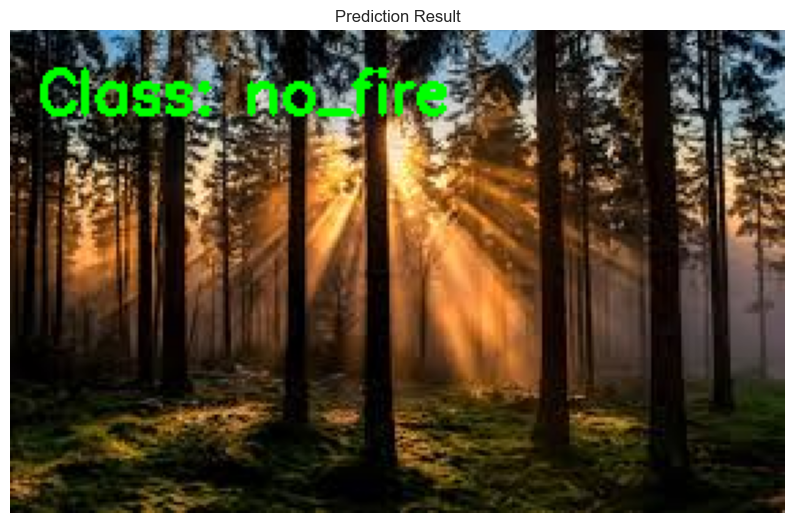

In [7]:
import cv2
import numpy as np
import tensorflow
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

MODEL_PATH = 'FirenetCNN1.h5'
IMAGE_PATH = ('download.jpeg')
TARGET_SIZE = (224, 224)

CLASS_LABELS = ['no_fire', 'fire', 'smoke']
model = load_model(MODEL_PATH, compile=False)


image = cv2.imread(IMAGE_PATH)
if image is None:
    print(f"Error: Could not read image from {IMAGE_PATH}")
else:

    input_image = cv2.resize(image, TARGET_SIZE)

    input_image = input_image / 255.0 

    input_image = np.expand_dims(input_image, axis=0)

    preds = model.predict(input_image)

    confidence = np.max(preds[0])
    class_index = np.argmax(preds[0])
    label = CLASS_LABELS[class_index]

    result_text = (f"Class: {label} ")
    result_text_2=(f"(Confidence: {confidence*100:.2f}%)")
    print(result_text,result_text_2)

    cv2.putText(image, result_text,
                (10, 30), # Position
                cv2.FONT_HERSHEY_SIMPLEX, 
                0.7, # Font scale
                (0, 255, 0), # Color (green)
                2) # Thickness

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 8))
    plt.imshow(image_rgb)
    plt.title("Prediction Result")
    plt.axis("off")
    plt.show()


In [8]:
import matplotlib.pyplot as plt
import numpy as np

imgs, labels = next(test_generator)
MODEL_PATH = 'FirenetCNN1.h5'
TARGET_SIZE = (224, 224)
CLASS_LABELS = ['fire', 'no_fire', 'smoke']

model = load_model(MODEL_PATH, compile=False)

predictions = model.predict(imgs)


plt.figure(figsize=(20, 20))

for i in range(25):  # Loop through 25 images
    if i >= len(imgs):
        break

    ax = plt.subplot(5, 5, i + 1)

    plt.imshow(imgs[i])


    predicted_index = np.argmax(predictions[i])
    actual_index = np.argmax(labels[i])

    predicted_label = CLASS_LABELS[predicted_index]
    actual_label = CLASS_LABELS[actual_index]
    confidence = np.max(predictions[i]) * 100


    if predicted_index == actual_index:
        color = 'green'
    else:
        color = 'red'

    # Set the title with prediction info
    plt.title(f"Pred: {predicted_label} ({confidence:.1f}%)\nTrue: {actual_label}",
              color=color, fontsize=12)

    plt.axis("off")

plt.tight_layout()
plt.show()

NameError: name 'test_generator' is not defined

In [6]:
import cv2
import numpy as np
import tensorflow
from tensorflow.keras.models import load_model


MODEL_PATH = 'FirenetCNN1.h5'
VIDEO_PATH = '177061-856658345.mp4'
TARGET_SIZE = (224, 224)

CLASS_LABELS = ['no_fire', 'fire', 'smoke']


model = load_model(MODEL_PATH, compile=False)

cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    print(f"Error: Could not open video file {VIDEO_PATH}")
else:
    print("Video processing... Press 'q' to quit.")
    while cap.isOpened():
        ret, frame = cap.read()

        if not ret:
            break

        input_frame = cv2.resize(frame, TARGET_SIZE)
        input_frame = input_frame / 255.0
        input_frame = np.expand_dims(input_frame, axis=0)

        preds = model.predict(input_frame)
        confidence = np.max(preds[0])
        class_index = np.argmax(preds[0])
        label = CLASS_LABELS[class_index]

        result_text = f"Class: {label} ({confidence*100:.2f}%)"

        color = (0, 255, 0)
        if label == 'fire':
            color = (0, 0, 255)
        elif label == 'smoke':
            color = (0, 255, 255)

        cv2.putText(frame, result_text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)

        cv2.imshow("Video Inference", frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()

Video processing... Press 'q' to quit.
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms

In [9]:
import cv2
import numpy as np
import tensorflow
from tensorflow.keras.models import load_model

MODEL_PATH = 'FirenetCNN1.h5'
VIDEO_PATH = 'WhatsApp Video 2026-03-01 at 4.29.57 PM.mp4'
TARGET_SIZE = (224, 224)


CLASS_LABELS = ['no_fire', 'fire', 'smoke']

model = load_model(MODEL_PATH, compile=False)

cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    print(f"Error: Could not open video file {VIDEO_PATH}")
else:
    print("Video processing... Press 'q' to quit.")
    while cap.isOpened():
        ret, frame = cap.read()

        if not ret:
            break

        input_frame = cv2.resize(frame, TARGET_SIZE)
        input_frame = input_frame / 255.0
        input_frame = np.expand_dims(input_frame, axis=0)

        preds = model.predict(input_frame)
        confidence = np.max(preds[0])
        class_index = np.argmax(preds[0])
        label = CLASS_LABELS[class_index]

        result_text = f"Class: {label} ({confidence*100:.2f}%)"

        color = (0, 255, 0)
        if label == 'fire':
            color = (0, 0, 255)
        elif label == 'smoke':
            color = (0, 255, 255)

        cv2.putText(frame, result_text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)


        cv2.imshow("Video Inference", frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()

Video processing... Press 'q' to quit.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [9]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model, Model


MODEL_PATH = 'FirenetCNN1.h5'
IMAGE_PATH = 'Burnout_ops_on_Mangum_Fire_McCall_Smokejumpers.jpg'
TARGET_SIZE = (224, 224)


CLASS_LABELS = ['no_fire', 'fire', 'smoke']


def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index):
    """Creates a Grad-CAM heatmap."""

    grad_model = Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )


    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)


    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def overlay_heatmap(original_img, heatmap, alpha=0.4):
    """Applies the heatmap to the original image."""

    heatmap = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))


    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = heatmap * alpha + original_img
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)
    return superimposed_img

model = load_model(MODEL_PATH, compile=False)

LAST_CONV_LAYER_NAME = 'out_relu'

image = cv2.imread(IMAGE_PATH)
if image is None:
    print(f"Error: Could not read image from {IMAGE_PATH}")
else:
    original_image = image.copy()
    input_image = cv2.resize(image, TARGET_SIZE)
    input_image_scaled = input_image / 255.0
    input_image_batch = np.expand_dims(input_image_scaled, axis=0)


    preds = model.predict(input_image_batch)
    confidence = np.max(preds[0])
    class_index = np.argmax(preds[0])
    label = CLASS_LABELS[class_index]

    superimposed_img = image.copy()
    if label != 'no_fire':
        heatmap = make_gradcam_heatmap(input_image_batch, model, LAST_CONV_LAYER_NAME, class_index)
        superimposed_img = overlay_heatmap(image, heatmap, alpha=0.5)

    result_text = f"Class: {label} ({confidence*100:.2f}%)"

    (text_width, text_height), baseline = cv2.getTextSize(result_text, cv2.FONT_HERSHEY_SIMPLEX, 1, 2)


    text_x, text_y = 10, 40

    cv2.rectangle(superimposed_img,
                  (text_x, text_y - text_height - baseline),
                  (text_x + text_width, text_y + baseline),
                  (0, 0, 0),
                  cv2.FILLED)

    color = (0, 255, 0)
    if label == 'fire':
        color = (0, 0, 255)
    elif label == 'smoke':
        color = (0, 255, 255)

    cv2.putText(superimposed_img, result_text, (text_x, text_y),
                cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)

    cv2.imshow("Prediction Result with Grad-CAM", superimposed_img)
    print(f"Predicted: {result_text}")
    print("Press any key to close.")
    cv2.waitKey(0)
    cv2.destroyAllWindows()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


C:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Predicted: Class: fire (95.20%)
Press any key to close.


In [10]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model, Model

MODEL_PATH = 'FirenetCNN1.h5'
VIDEO_PATH = '3068-165796695_small.mp4'
TARGET_SIZE = (224, 224)
CLASS_LABELS = ['no_fire', 'fire', 'smoke']


PREDICT_EVERY_N_FRAMES = 10

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index):
    grad_model = Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        class_channel = preds[:, pred_index]
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def overlay_heatmap(original_img, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = heatmap * alpha + original_img
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)
    return superimposed_img

model = load_model(MODEL_PATH, compile=False)
LAST_CONV_LAYER_NAME = 'out_relu'


cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    print(f"Error: Could not open video file {VIDEO_PATH}")
else:
    print("Video processing... Press 'q' to quit.")

    frame_count = 0
    last_label = "Initializing..."
    last_confidence = 0
    last_heatmap = None
    last_color = (255, 255, 255) # White

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_count += 1
        display_frame = frame.copy()

        if frame_count % PREDICT_EVERY_N_FRAMES == 0:
            input_frame = cv2.resize(frame, TARGET_SIZE)
            input_frame_scaled = input_frame / 255.0
            input_frame_batch = np.expand_dims(input_frame_scaled, axis=0)

            preds = model.predict(input_frame_batch)
            last_confidence = np.max(preds[0])
            class_index = np.argmax(preds[0])
            last_label = CLASS_LABELS[class_index]

            if last_label == 'fire':
                last_color = (0, 0, 255) # Red
            elif last_label == 'smoke':
                last_color = (0, 255, 255) # Yellow
            else:
                last_color = (0, 255, 0) # Green

            if last_label != 'no_fire':
                last_heatmap = make_gradcam_heatmap(input_frame_batch, model, LAST_CONV_LAYER_NAME, class_index)
            else:
                last_heatmap = None


        if last_heatmap is not None:
            display_frame = overlay_heatmap(display_frame, last_heatmap, alpha=0.5)


        result_text = f"Class: {last_label} ({last_confidence*100:.2f}%)"

        (text_width, text_height), baseline = cv2.getTextSize(result_text, cv2.FONT_HERSHEY_SIMPLEX, 1, 2)
        text_x, text_y = 10, 40

        cv2.rectangle(display_frame,
                      (text_x, text_y - text_height - baseline),
                      (text_x + text_width, text_y + baseline),
                      (0, 0, 0), cv2.FILLED)

        cv2.putText(display_frame, result_text, (text_x, text_y),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, last_color, 2)


        cv2.imshow("Video Inference with Grad-CAM", display_frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break


cap.release()
cv2.destroyAllWindows()

Video processing... Press 'q' to quit.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


C:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


In [37]:
import cv2
import numpy as np
import tensorflow
from tensorflow.keras.models import load_model

MODEL_PATH = 'FirenetCNN1.h5'
TARGET_SIZE = (224, 224)
CLASS_LABELS = ['fire', 'no_fire', 'smoke']

model = load_model(MODEL_PATH, compile=False)

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open webcam.")
else:
    print("Webcam started... Press 'q' to quit.")

    while True:
        # Read one frame from the webcam
        ret, frame = cap.read()
        if not ret:
            print("Error: Failed to capture frame.")
            break

        input_frame = cv2.resize(frame, TARGET_SIZE)
        input_frame = input_frame / 255.0  # Rescale
        input_frame = np.expand_dims(input_frame, axis=0) # Create batch

        preds = model.predict(input_frame, verbose=0)
        confidence = np.max(preds[0])
        class_index = np.argmax(preds[0])
        label = CLASS_LABELS[class_index]

        result_text = f"Class: {label} ({confidence*100:.2f}%)"

        color = (0, 255, 0) # Green for no_fire
        if label == 'fire':
            color = (0, 0, 255) # Red
        elif label == 'smoke':
            color = (0, 255, 255) # Yellow

        (text_width, text_height), baseline = cv2.getTextSize(result_text, cv2.FONT_HERSHEY_SIMPLEX, 1, 2)
        text_x, text_y = 10, 40

        cv2.rectangle(frame,
                      (text_x - 5, text_y - text_height - baseline - 5),
                      (text_x + text_width + 5, text_y + baseline + 5),
                      (0, 0, 0), # Black background
                      cv2.FILLED)

        cv2.putText(frame, result_text, (text_x, text_y),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)

        # Display the frame
        cv2.imshow("Live Webcam Inference (Slow)", frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

# Release resources
cap.release()
cv2.destroyAllWindows()

Webcam started... Press 'q' to quit.


# Model Evaluation

In [12]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:

MODEL_PATH = 'FirenetCNN1.h5'
TEST_DIR = 'data/forestfire-classifier-dataset/test'
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32


CLASS_LABELS = ['fire', 'no_fire', 'smoke']


In [14]:

test_datagen = ImageDataGenerator(rescale=1./255.)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Found {test_generator.n} images in {test_generator.num_classes} classes.")
print("Class indices:", test_generator.class_indices)

Found 405 images belonging to 3 classes.
Found 405 images in 3 classes.
Class indices: {'fire': 0, 'nofire': 1, 'smoke': 2}


In [15]:
model = load_model(MODEL_PATH, compile=False)
Y_pred_probs = model.predict(test_generator)
y_pred_indices = np.argmax(Y_pred_probs, axis=1)
y_true_indices = test_generator.classes

C:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


13/13 ━━━━━━━━━━━━━━━━━━━━ 72s 6s/step


In [16]:
print("\n--- Classification Report ---")

print(classification_report(y_true_indices, y_pred_indices, target_names=CLASS_LABELS))

cm = confusion_matrix(y_true_indices, y_pred_indices)



--- Classification Report ---
              precision    recall  f1-score   support

        fire       0.92      0.81      0.86       121
     no_fire       0.76      0.98      0.86       146
       smoke       0.84      0.67      0.75       138

    accuracy                           0.82       405
   macro avg       0.84      0.82      0.82       405
weighted avg       0.83      0.82      0.82       405




--- Plotting Confusion Matrix ---


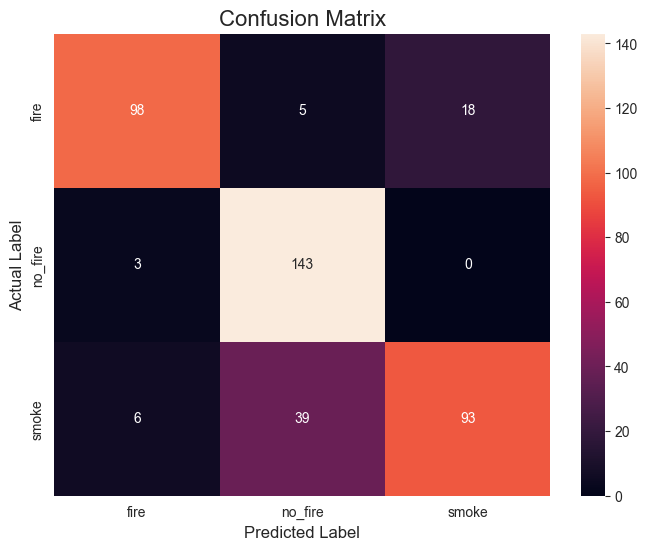

In [17]:
print("\n--- Plotting Confusion Matrix ---")

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=CLASS_LABELS,
    yticklabels=CLASS_LABELS
)

plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()